In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.ticker as mticker
from IPython.display import Image, display

# GPU price (chatGPT)

Among the GPUs you listed (T4, A40, A100, P100, V100), the typical current market price order (from cheapest to most expensive) in 2025-2026 server markets is approximately:

1. NVIDIA Tesla T4

    * Lowest cost
    
    * Used heavily for inference and light compute
    
    * Typical used price: USD 400 - USD 900

2. NVIDIA Tesla P100

    * Older Pascal architecture
    
    * Often found in older clusters
    
    * Typical used price: USD500-USD1200

3. NVIDIA Tesla V100

    * Volta architecture
    
    * Still common in HPC
    
    * Typical used price: USD1500-USD4000

4. NVIDIA A40

    * Ampere architecture (data center / workstation)
    
    * Strong FP32 and large VRAM (48 GB)
    
    * Typical price: USD4500-USD7000

5. NVIDIA A100

    * Top data-center compute GPU in this list
    
    * Used heavily for AI and HPC
    
    * Typical price: USD 8000-USD15000+ depending on 40GB or 80GB

# Plots:

### Panel a: Total simulation throughput

Panel **a** shows the **total simulation time produced per GPU per day** when multiple replicas run in parallel. The y-axis reports **μs/day**, calculated as

$
Total \mu s = \frac{\text{copies} \times \text{average ns/day}}{1000}
$

where **copies** is the number chains in single simulation and **average ns/day** is the average speed of a single trajectory (average from 3 independent runs). This panel reflects the **overall GPU throughput**.

### Panel b: Trajectory length per simulation

Panel **b** shows the **speed of individual trajectories** as the number of replicas increases. The y-axis reports **ns/day per simulation**.

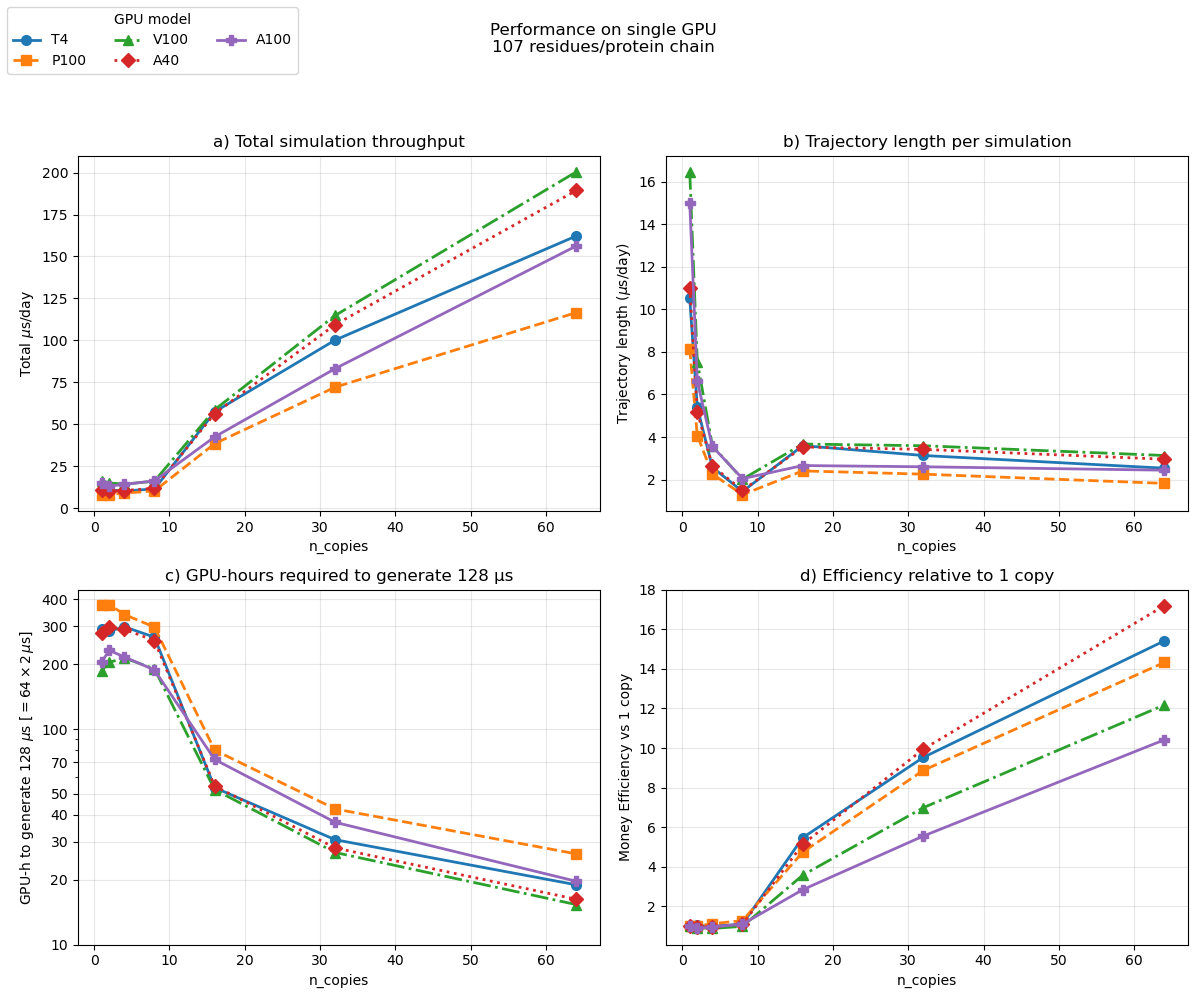

In [2]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# from pathlib import Path

gpu_models = ['T4', 'P100', 'V100', 'A40', 'A100']

markers = ['o', 's', '^', 'D', 'P']
linestyles = ['-', '--', '-.', ':', '-']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax_a = axes[0, 0]
ax_b = axes[0, 1]
ax_c = axes[1, 0]
ax_d = axes[1, 1]

for gpu, m, ls in zip(gpu_models, markers, linestyles):
    file_path = Path(f'107_res/{gpu}/bench.xlsx')

    if not file_path.exists():
        print(f"Missing file for {gpu}")
        continue

    df = pd.read_excel(file_path).copy()

    # sort by copies in case the sheet is unordered
    df = df.sort_values('copies').reset_index(drop=True)

    # panel a: total throughput
    df['total_sim_length_musec_per_day'] = df['copies'] * df['ns/day_avg'] / 1000

    ax_a.plot(
        df['copies'],
        df['total_sim_length_musec_per_day'],
        marker=m,
        linestyle=ls,
        linewidth=2,
        markersize=7,
        label=gpu
    )

    # panel b: trajectory speed
    ax_b.plot(
        df['copies'],
        df['ns/day_avg'] / 1000,
        marker=m,
        linestyle=ls,
        linewidth=2,
        markersize=7
    )

    # panel c: GPU-hours to generate 128 us
    df['gpu_hours_to_128us'] = 128 / df['total_sim_length_musec_per_day'] * 24

    ax_c.plot(
        df['copies'],
        df['gpu_hours_to_128us'],
        marker=m,
        linestyle=ls,
        linewidth=2,
        markersize=7
    )

    # panel d: fold savings relative to 1 copy
    if 1 in df['copies'].values:
        gpu_hours_1copy = df.loc[df['copies'] == 1, 'gpu_hours_to_128us'].iloc[0]
        df['fold_saved_vs_1copy'] = gpu_hours_1copy / df['gpu_hours_to_128us']

        ax_d.plot(
            df['copies'],
            df['fold_saved_vs_1copy'],
            marker=m,
            linestyle=ls,
            linewidth=2,
            markersize=7
        )
    else:
        print(f"Warning: {gpu} does not have copies = 1, so panel d was skipped for this GPU.")

# formatting
ax_a.set_xlabel('n_copies')
ax_a.set_ylabel(r'Total $\mu$s/day')
ax_a.set_title('a) Total simulation throughput')
ax_a.grid(alpha=0.3)

ax_b.set_xlabel('n_copies')
ax_b.set_ylabel(r'Trajectory length ($\mu$s/day)')
ax_b.set_title('b) Trajectory length per simulation')
ax_b.grid(alpha=0.3)

ax_c.set_xlabel('n_copies')
ax_c.set_ylabel(r'GPU-h to generate 128 $\mu$s [$=64 \times 2\,\mu$s]')
ax_c.set_title('c) GPU-hours required to generate 128 μs')
ax_c.grid(alpha=0.3)
ax_c.set_yscale('log')
ax_c.set_yticks([10, 20, 30, 40, 50, 70, 100, 200, 300, 400])
ax_c.get_yaxis().set_major_formatter(mticker.ScalarFormatter())

ax_d.set_xlabel('n_copies')
ax_d.set_ylabel('Money Efficiency vs 1 copy')
ax_d.set_title('d) Efficiency relative to 1 copy')
ax_d.grid(alpha=0.3)

# shared legend
handles, labels = ax_a.get_legend_handles_labels()
fig.legend(handles, labels, title='GPU model', loc='upper left', ncol=3)

fig.suptitle('Performance on single GPU\n107 residues/protein chain')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

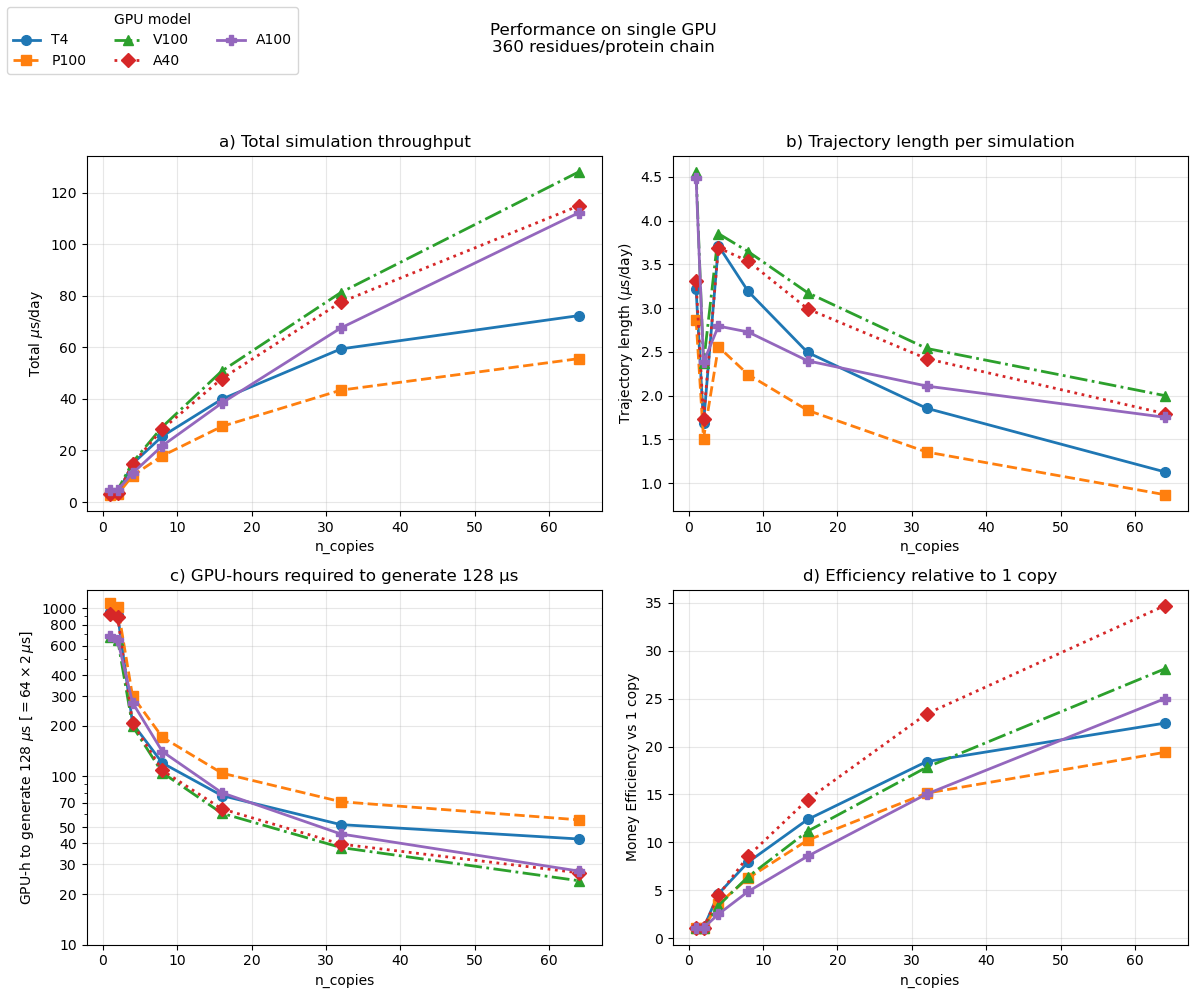

In [3]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# from pathlib import Path

gpu_models = ['T4', 'P100', 'V100', 'A40', 'A100']

markers = ['o', 's', '^', 'D', 'P']
linestyles = ['-', '--', '-.', ':', '-']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax_a = axes[0, 0]
ax_b = axes[0, 1]
ax_c = axes[1, 0]
ax_d = axes[1, 1]

for gpu, m, ls in zip(gpu_models, markers, linestyles):
    file_path = Path(f'360_res/{gpu}/bench.xlsx')

    if not file_path.exists():
        print(f"Missing file for {gpu}")
        continue

    df = pd.read_excel(file_path).copy()

    # sort by copies in case the sheet is unordered
    df = df.sort_values('copies').reset_index(drop=True)

    # panel a: total throughput
    df['total_sim_length_musec_per_day'] = df['copies'] * df['ns/day_avg'] / 1000

    ax_a.plot(
        df['copies'],
        df['total_sim_length_musec_per_day'],
        marker=m,
        linestyle=ls,
        linewidth=2,
        markersize=7,
        label=gpu
    )

    # panel b: trajectory speed
    ax_b.plot(
        df['copies'],
        df['ns/day_avg'] / 1000,
        marker=m,
        linestyle=ls,
        linewidth=2,
        markersize=7
    )

    # panel c: GPU-hours to generate 128 us
    df['gpu_hours_to_128us'] = 128 / df['total_sim_length_musec_per_day'] * 24

    ax_c.plot(
        df['copies'],
        df['gpu_hours_to_128us'],
        marker=m,
        linestyle=ls,
        linewidth=2,
        markersize=7
    )

    # panel d: fold savings relative to 1 copy
    if 1 in df['copies'].values:
        gpu_hours_1copy = df.loc[df['copies'] == 1, 'gpu_hours_to_128us'].iloc[0]
        df['fold_saved_vs_1copy'] = gpu_hours_1copy / df['gpu_hours_to_128us']

        ax_d.plot(
            df['copies'],
            df['fold_saved_vs_1copy'],
            marker=m,
            linestyle=ls,
            linewidth=2,
            markersize=7
        )
    else:
        print(f"Warning: {gpu} does not have copies = 1, so panel d was skipped for this GPU.")

# formatting
ax_a.set_xlabel('n_copies')
ax_a.set_ylabel(r'Total $\mu$s/day')
ax_a.set_title('a) Total simulation throughput')
ax_a.grid(alpha=0.3)

ax_b.set_xlabel('n_copies')
ax_b.set_ylabel(r'Trajectory length ($\mu$s/day)')
ax_b.set_title('b) Trajectory length per simulation')
ax_b.grid(alpha=0.3)

ax_c.set_xlabel('n_copies')
ax_c.set_ylabel(r'GPU-h to generate 128 $\mu$s [$=64 \times 2\,\mu$s]')
ax_c.set_title('c) GPU-hours required to generate 128 μs')
ax_c.grid(alpha=0.3)
ax_c.set_yscale('log')
ax_c.set_yticks([10, 20, 30, 40, 50, 70, 100, 200, 300, 400, 600, 800, 1000])
ax_c.get_yaxis().set_major_formatter(mticker.ScalarFormatter())

ax_d.set_xlabel('n_copies')
ax_d.set_ylabel('Money Efficiency vs 1 copy')
ax_d.set_title('d) Efficiency relative to 1 copy')
ax_d.grid(alpha=0.3)

# shared legend
handles, labels = ax_a.get_legend_handles_labels()
fig.legend(handles, labels, title='GPU model', loc='upper left', ncol=3)

fig.suptitle('Performance on single GPU\n360 residues/protein chain')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# Compare Free Energy surface of protein folding (360 residues)

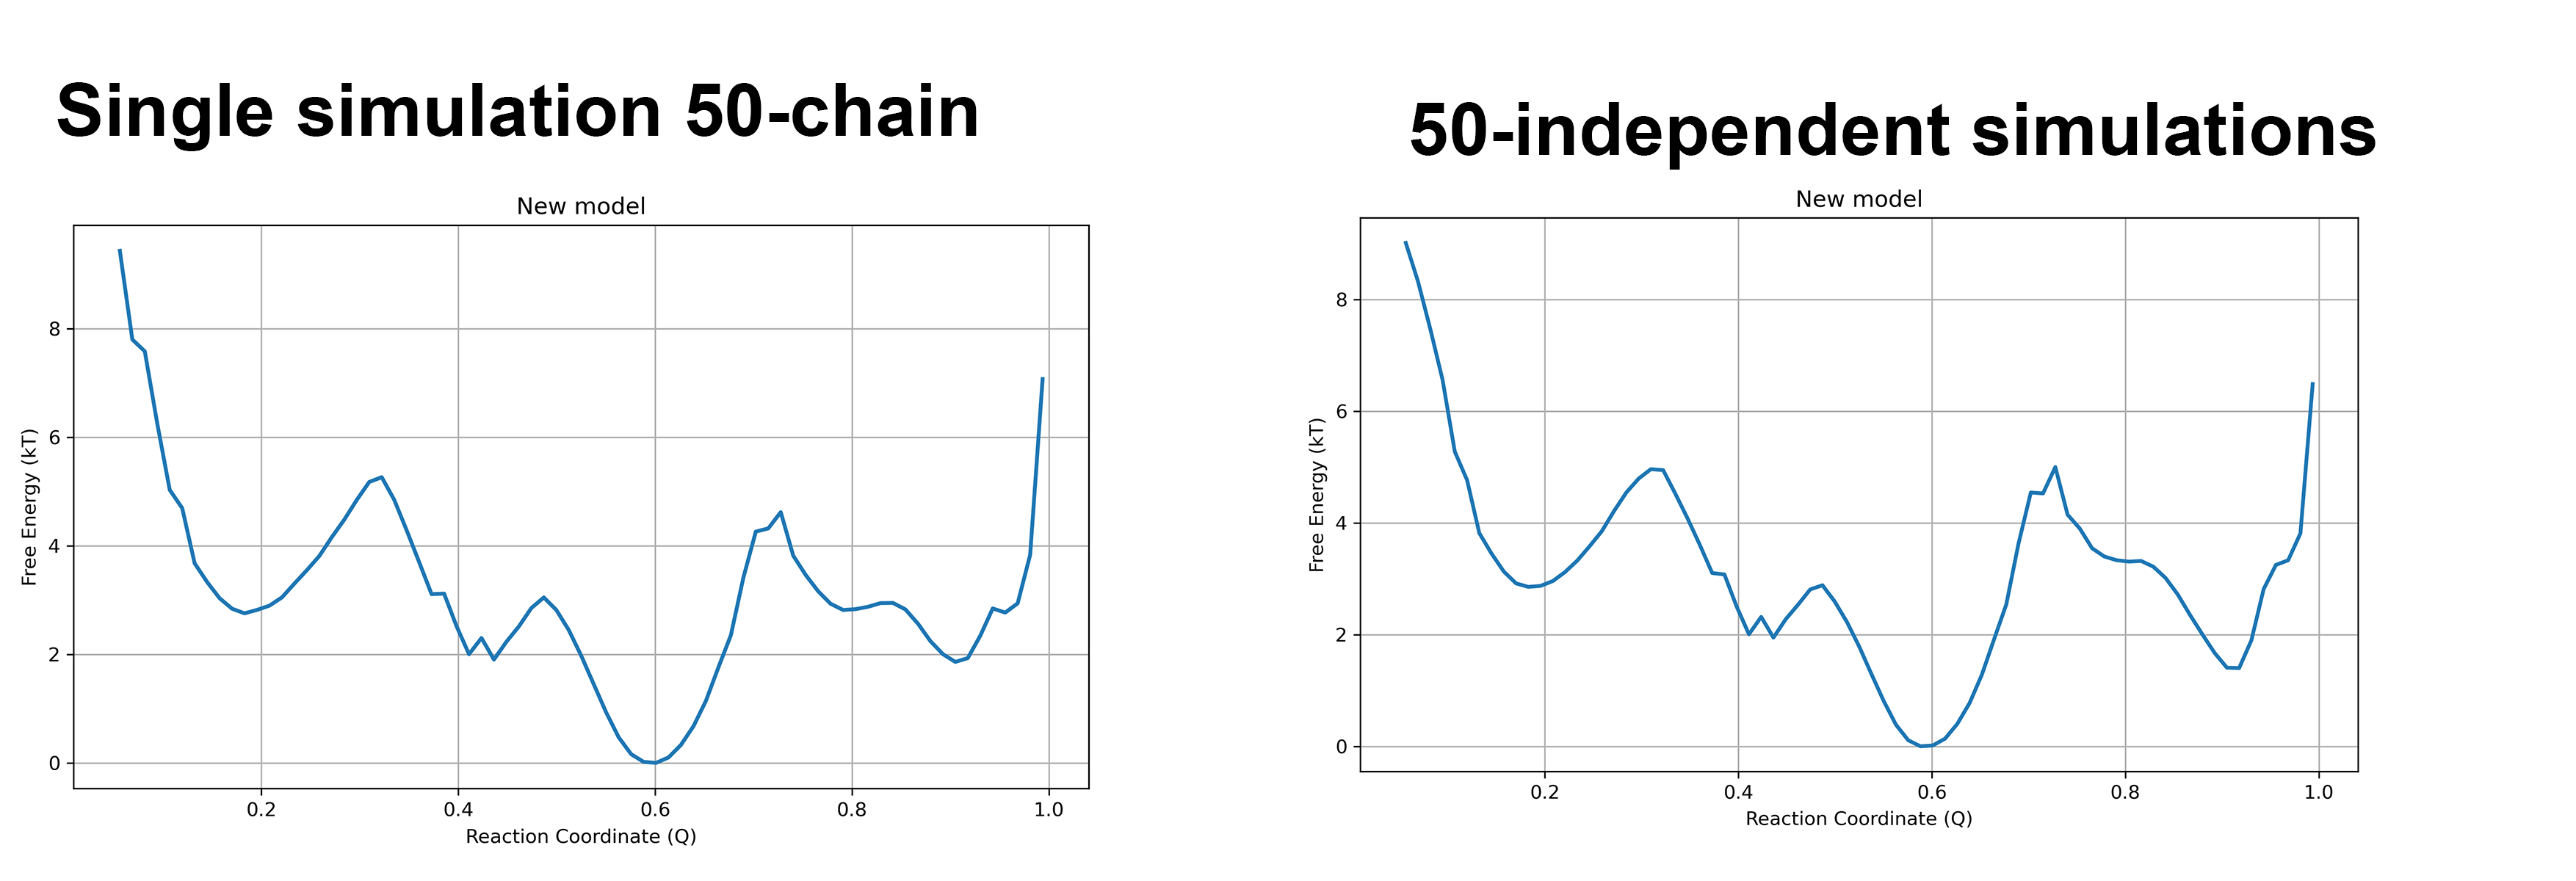

In [4]:
# <!-- ![1D FE on Q]() -->
display(Image("1D_Q_FE_Compare.png", width=1600))
# <!-- display(Image("image2.png")) -->

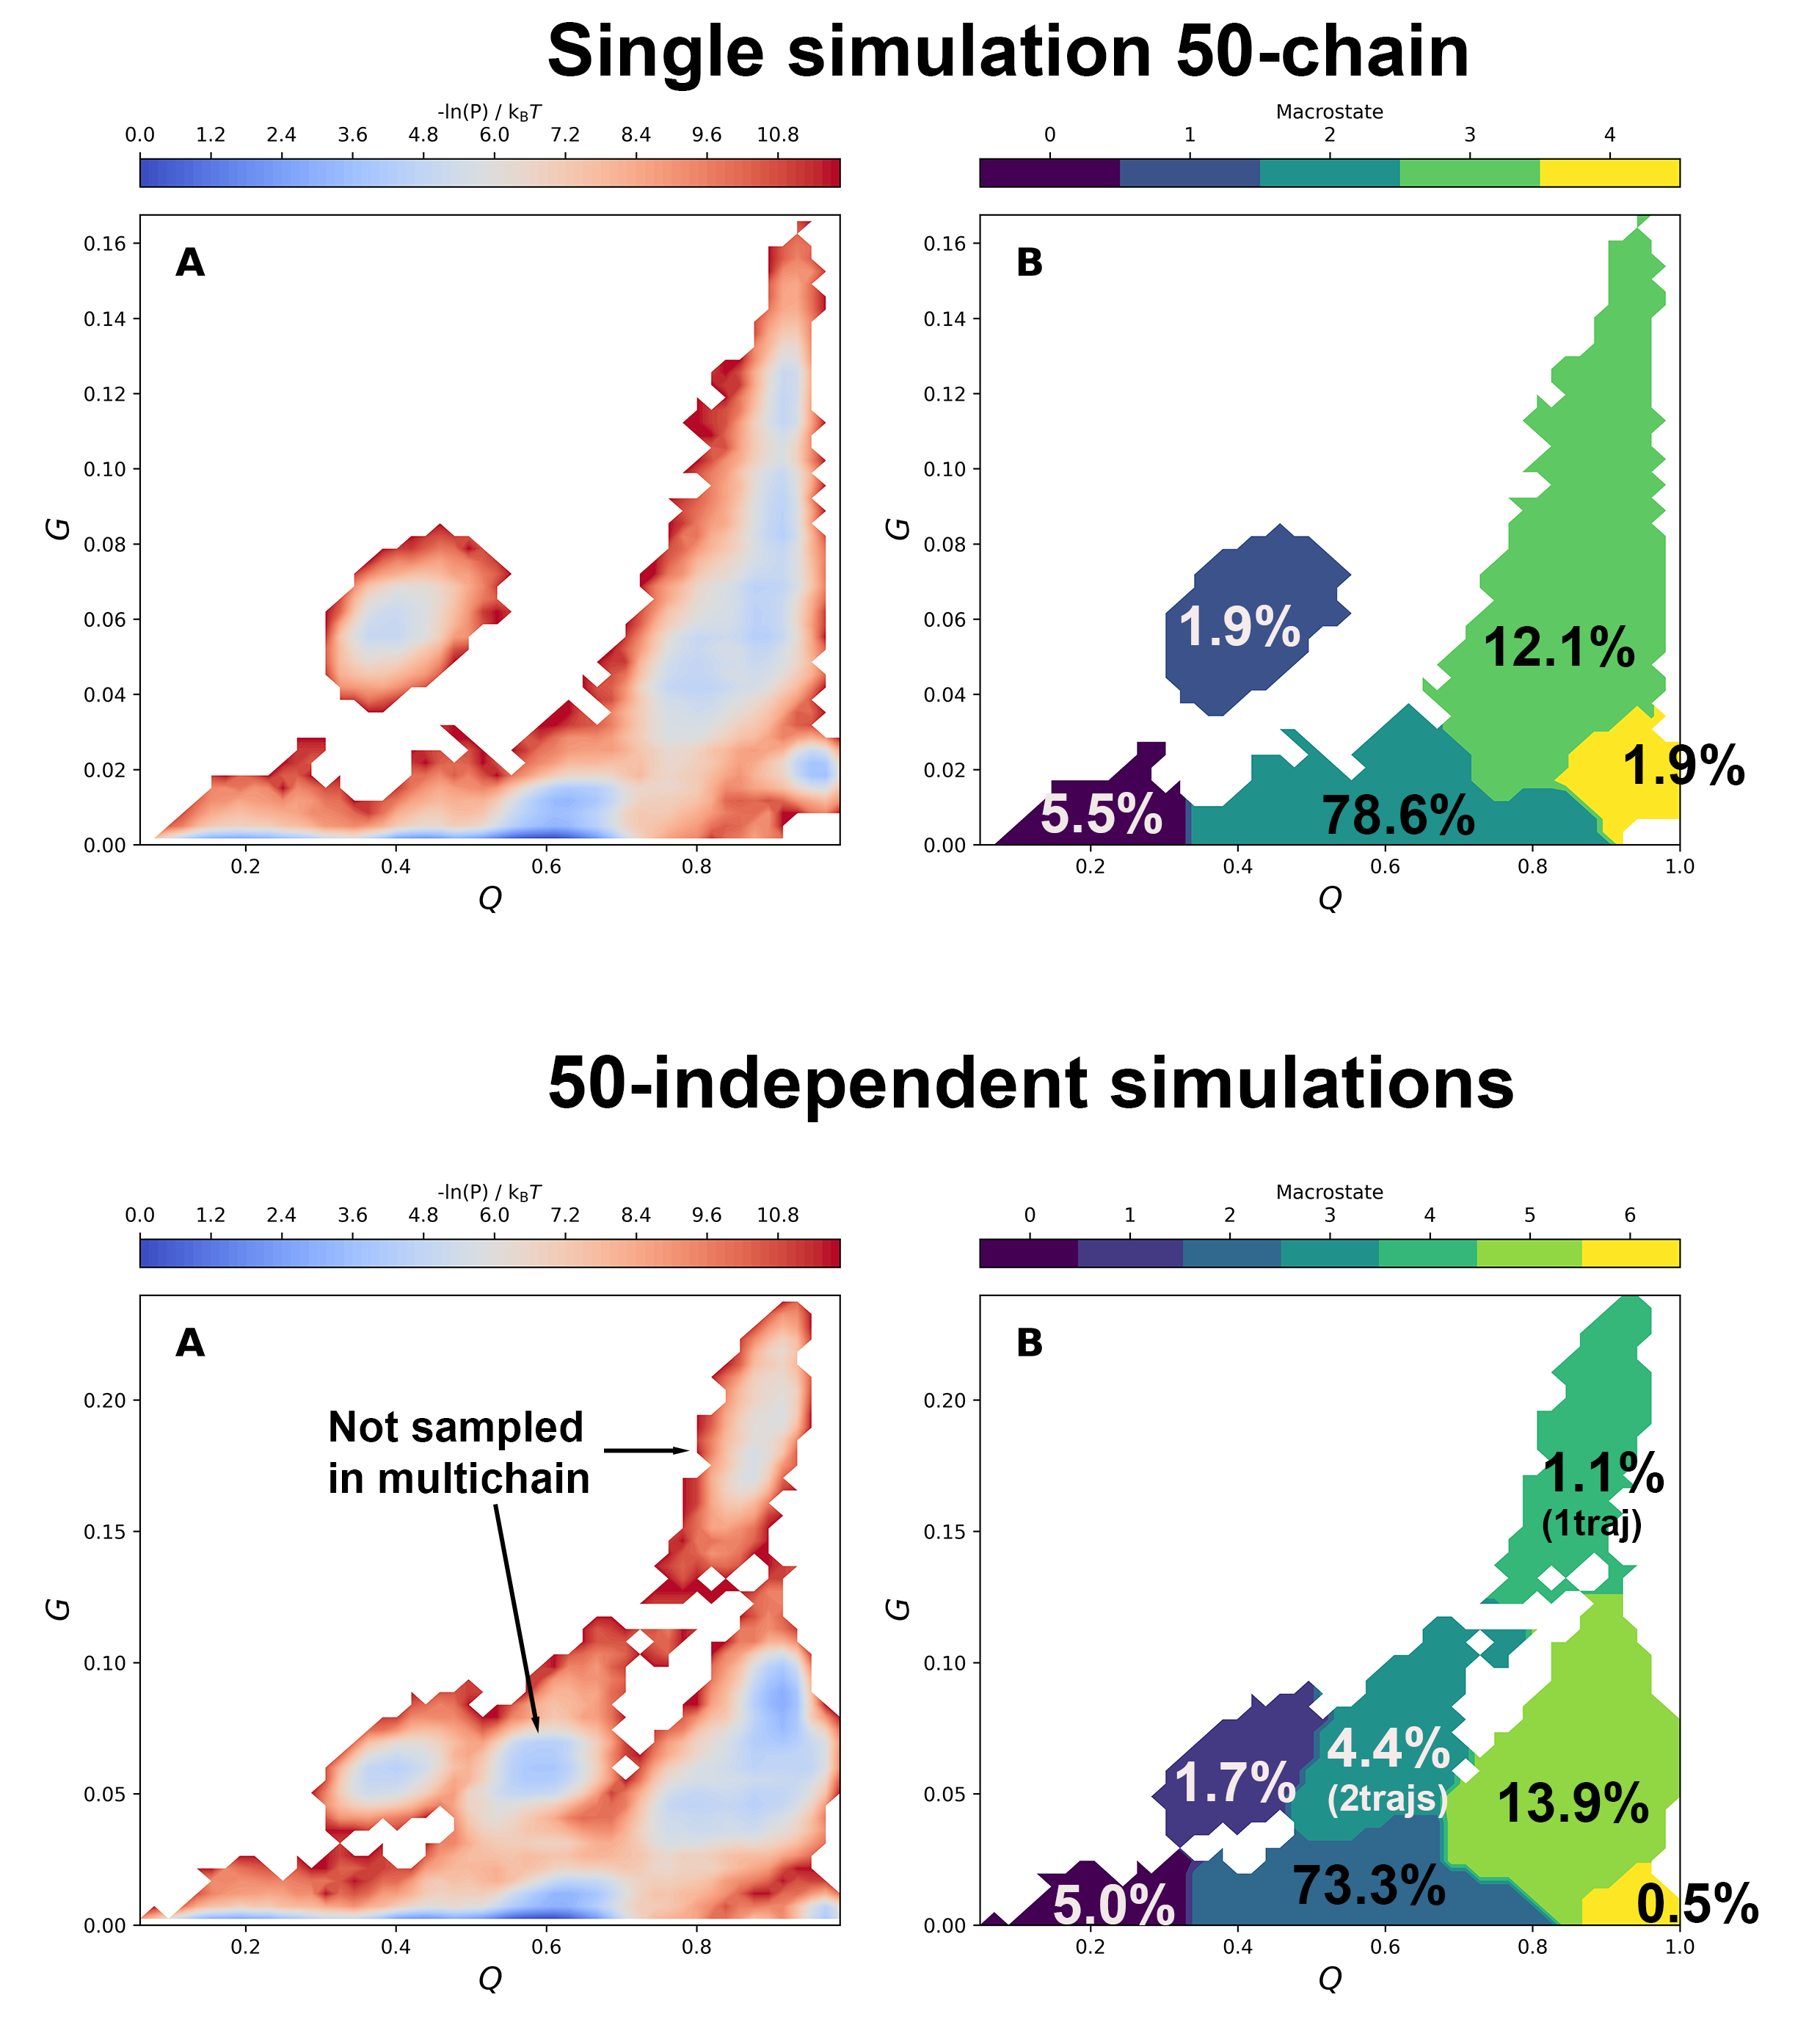

In [5]:
# <!-- ![2D FE on QG](2D_FE_Compare.png) -->
display(Image("2D_FE_Compare.png", width=1600))